# Phase 4 — XGBoost

End-to-end XGBoost workflow:
1. **EDA** — feature distributions, target relationship, leakage sanity, univariate predictive power
2. Training (next session) — hyperparameter from `src.models.config`, val early stopping, save artifacts
3. SHAP analysis (next session) — global importance + dependence plots on top features

In [1]:
%load_ext autoreload
%autoreload 2

import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

from src.models.data_loaders import load_xgb_split, class_imbalance_ratio

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_rows", 80)

## 1. Exploratory Data Analysis

EDA is done on **train split only** — val/test stay sealed for honest evaluation.

### 1.1 Load and schema check

In [2]:
X_train, y_train = load_xgb_split("train")
print(f"Shape: X={X_train.shape}  y={y_train.shape}")
print(f"Churn rate: {y_train.mean():.1%}  ({int(y_train.sum()):,} / {len(y_train):,})")
print(f"Class imbalance ratio (neg/pos): {class_imbalance_ratio(y_train):.2f}")
print(f"Feature dtypes:")
print(X_train.dtypes.value_counts())

Shape: X=(34999, 42)  y=(34999,)
Churn rate: 12.2%  (4,279 / 34,999)
Class imbalance ratio (neg/pos): 7.18
Feature dtypes:
float64    33
int64       5
int32       4
Name: count, dtype: int64


### 1.2 Per-persona churn (sanity reminder)

Cross-check with the data-generation design: only `about_to_churn` and a sliver of `casual` should be churners. If we see hardcore/regular at non-zero, something drifted.

In [4]:
users = pd.read_parquet("../data/raw/users.parquet", columns=["user_id","persona"])
train_personas = X_train.join(users.set_index("user_id"), how="left")
churn_by_persona = train_personas.assign(churn=y_train.values).groupby("persona")["churn"].agg(["sum","count","mean"])
print(churn_by_persona)

                 sum  count   mean
persona                           
about_to_churn  3919   5193 0.7547
casual           341  10623 0.0321
hardcore           0   7015 0.0000
regular           19  12168 0.0016


### 1.3 Missingness inventory

XGBoost handles NaN natively (it learns a default direction at each split). We still want to know which features are sparse — high NaN rate means low signal.

In [5]:
null_count = X_train.isnull().sum()
null_pct = (null_count / len(X_train) * 100).round(1)
null_df = pd.DataFrame({"nulls": null_count, "pct": null_pct})
null_df = null_df[null_df["nulls"] > 0].sort_values("pct", ascending=False)
print(null_df.to_string())

                                nulls     pct
days_since_last_payment          6777 19.4000
payment_frequency_change         5723 16.4000
playtime_wow_change_last         3640 10.4000
session_count_wow_change_last    3640 10.4000
new_game_trial_rate_last         2304  6.6000
crash_exit_ratio_last            1860  5.3000
session_duration_std             1609  4.6000
playtime_vs_baseline_last         373  1.1000
session_count_vs_baseline_last    373  1.1000
daily_playtime_cv                 122  0.3000
avg_latency                       122  0.3000
avg_fps                           122  0.3000
top_game_concentration            122  0.3000
unique_games_played               122  0.3000
crash_exit_ratio                  122  0.3000
packet_loss_avg                   122  0.3000
avg_jitter                        122  0.3000
avg_bitrate                       122  0.3000
disconnect_rate                   122  0.3000
frame_drop_rate                   122  0.3000
genre_entropy                     

### 1.4 Feature mean by churn class

Big mean shift = strong univariate signal. Look for ratios like `last_week_sessions: 9.7 → 1.4` (factor of 7x).

In [7]:
class_means = X_train.assign(churn=y_train.values).groupby("churn").mean().T
class_means.columns = ["non_churn_mean", "churn_mean"]
class_means["ratio"] = class_means["churn_mean"] / class_means["non_churn_mean"].replace(0, np.nan)
class_means["abs_log_ratio"] = np.abs(np.log(class_means["ratio"].clip(lower=1e-6)))
# Top features by separation magnitude (ignoring NaN ratios from zero baselines)
class_means_sorted = class_means.sort_values("abs_log_ratio", ascending=False, na_position="last")
print(class_means_sorted.head(20).drop(columns="abs_log_ratio"))

                                non_churn_mean  churn_mean    ratio
playtime_slope                        140.3403    -78.6315  -0.5603
payment_frequency_change                0.1423     -0.0613  -0.4304
playtime_wow_change_last                0.2332     -0.3790  -1.6249
session_count_wow_change_last           0.0250     -0.4868 -19.4427
total_playtime_min_last              1105.2705     51.3430   0.0465
weekly_session_count_last               9.7229      1.4319   0.1473
total_playtime_min                    750.3685    138.1711   0.1841
total_playtime_min_norm                 1.9593      0.3917   0.1999
playtime_vs_baseline_last               2.0460      0.4502   0.2200
session_count_vs_baseline_last          1.8634      0.5437   0.2918
disconnect_rate                         0.3375      1.0914   3.2335
daily_playtime_std                     99.3788     32.2584   0.3246
weekly_session_count                    6.6091      2.3888   0.3614
crash_exit_ratio_last                   0.2574  

### 1.5 Univariate predictive power (AUC per feature)

For each feature, train a one-feature classifier (just rank by the feature value) and compute ROC-AUC against churn. Higher = more individually informative. This is more robust than linear correlation for non-monotonic features.

`roc_auc_score(y, x)` returns 0.5 for "no signal" — flip a feature with AUC < 0.5 and you get AUC > 0.5, so what matters is `|AUC − 0.5|`.

In [8]:
def univariate_auc(X, y):
    rows = []
    for col in X.columns:
        x = X[col].copy()
        if x.isnull().any():
            # Fill NaN with median for AUC computation; XGBoost handles NaN
            # natively at train time so this is only for the EDA ranking.
            x = x.fillna(x.median())
        if x.nunique() < 2:
            rows.append((col, np.nan, np.nan))
            continue
        auc = roc_auc_score(y, x)
        rows.append((col, auc, abs(auc - 0.5)))
    return pd.DataFrame(rows, columns=["feature","auc","abs_lift"]).sort_values("abs_lift", ascending=False).reset_index(drop=True)

ua = univariate_auc(X_train, y_train)
print("Top 15 features by univariate |AUC - 0.5|:")
print(ua.head(15).to_string(index=False))
print()
print("Bottom 10 (weakest univariate signal):")
print(ua.tail(10).to_string(index=False))

Top 15 features by univariate |AUC - 0.5|:
                       feature    auc  abs_lift
                playtime_slope 0.0707    0.4293
     playtime_vs_baseline_last 0.0935    0.4065
       total_playtime_min_last 0.0946    0.4054
session_count_vs_baseline_last 0.0977    0.4023
               disconnect_rate 0.8937    0.3937
     weekly_session_count_last 0.1152    0.3848
              crash_exit_ratio 0.8644    0.3644
    longest_inactive_days_last 0.8195    0.3195
 session_count_wow_change_last 0.2364    0.2636
      playtime_wow_change_last 0.2390    0.2610
        top_game_concentration 0.7492    0.2492
                 genre_entropy 0.2543    0.2457
               frame_drop_rate 0.7454    0.2454
         crash_exit_ratio_last 0.7441    0.2441
          weekly_session_count 0.2576    0.2424

Bottom 10 (weakest univariate signal):
                 feature    auc  abs_lift
              avg_jitter 0.5795    0.0795
             avg_latency 0.5606    0.0606
           weekend_rati

### 1.6 Leakage sanity

A single feature AUC ≥ 0.99 usually means leakage. None of our features should be that strong — they describe behavior *before* the prediction window, so they correlate but cannot perfectly predict.

In [9]:
suspicious = ua[ua["auc"].notna() & (ua["abs_lift"] > 0.48)]
if len(suspicious) > 0:
    print("WARN: feature(s) with |AUC - 0.5| > 0.48 (suspect leakage):")
    print(suspicious.to_string(index=False))
else:
    print("PASS: no single feature is suspiciously predictive (max abs_lift = {:.3f})".format(ua["abs_lift"].max()))

PASS: no single feature is suspiciously predictive (max abs_lift = 0.429)


### 1.7 Distribution plots for top 6 features

Visual check that the churn vs non-churn split is what we expect (decay features should show clear separation).

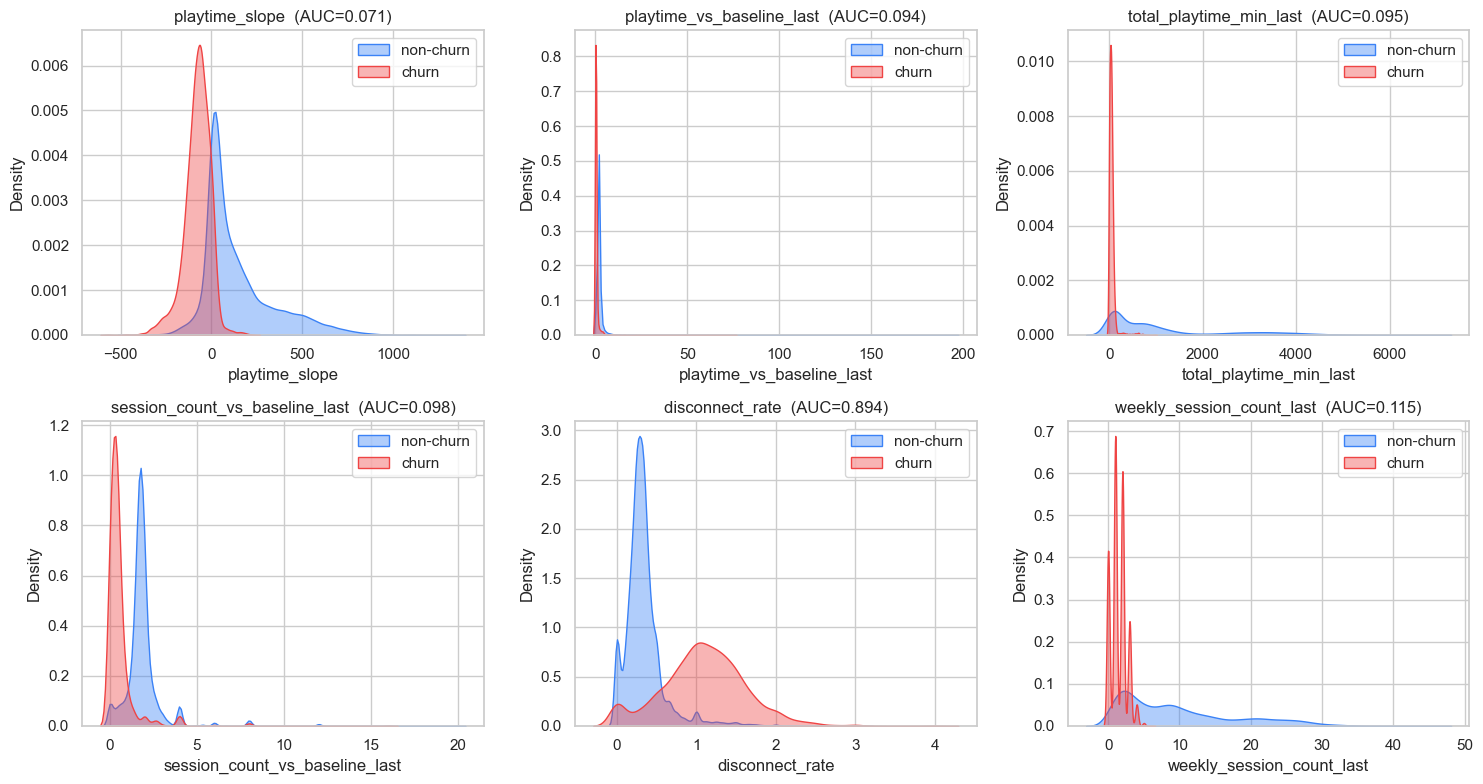

In [10]:
top6 = ua.head(6)["feature"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), top6):
    df_plot = X_train[[feat]].assign(churn=y_train.values).dropna()
    for c, label, color in [(0, "non-churn", "#3b82f6"), (1, "churn", "#ef4444")]:
        sns.kdeplot(
            df_plot.loc[df_plot["churn"] == c, feat],
            label=label, color=color, fill=True, alpha=0.4, ax=ax,
        )
    ax.set_title(f"{feat}  (AUC={ua.loc[ua.feature==feat,'auc'].iloc[0]:.3f})")
    ax.legend()
plt.tight_layout()
plt.show()

### 1.8 Feature inter-correlation

Trees are robust to correlated features (unlike linear models) but heavy correlation can dilute SHAP attribution. We just want to flag any pair > 0.95 in case we want to drop one later.

In [11]:
# Drop rows with NaN for the correlation matrix (per-pair pairwise would be cleaner)
corr = X_train.dropna().corr()
# Upper triangle, exclude diagonal
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = (
    corr.where(mask).stack().reset_index()
    .rename(columns={"level_0":"f1","level_1":"f2",0:"corr"})
)
high_corr = pairs[pairs["corr"].abs() > 0.85].sort_values("corr", key=abs, ascending=False)
print(f"Feature pairs with |corr| > 0.85: {len(high_corr)}")
print(high_corr.to_string(index=False))

Feature pairs with |corr| > 0.85: 45
                       f1                        f2    corr
     weekly_session_count weekly_session_count_norm  0.9996
       total_playtime_min   total_playtime_min_norm  0.9996
     weekly_session_count       unique_games_played  0.9978
weekly_session_count_norm       unique_games_played  0.9974
              avg_bitrate      current_tier_numeric  0.9902
     weekly_session_count weekly_session_count_last  0.9875
       total_playtime_min   total_playtime_min_last  0.9866
      unique_games_played weekly_session_count_last  0.9860
weekly_session_count_norm weekly_session_count_last  0.9834
  total_playtime_min_norm   total_playtime_min_last  0.9819
     weekly_session_count        total_playtime_min  0.9706
       total_playtime_min weekly_session_count_norm  0.9704
weekly_session_count_norm   total_playtime_min_norm  0.9703
     weekly_session_count   total_playtime_min_norm  0.9701
       total_playtime_min       unique_games_played  0.9677
  t

### 1.9 EDA summary

Expected findings (data design):
- Top univariate features should be variants of `weekly_session_count_last`, `total_playtime_min_last`, `playtime_slope`, `longest_inactive_days_last`, `crash_exit_ratio_last`.
- No single feature should have AUC ≥ 0.99 (no leakage).
- Strong correlation between `weekly_session_count` and `total_playtime_min` (and their `_norm` / `_last` variants) is expected — they're all measuring the same underlying behavior.
- `peak_hour_ratio`, `weekend_ratio`, `genre_entropy` should have low univariate AUC (timing / diversity is a weaker churn signal than volume/decay).